# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [10]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [11]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('Wholesale_customers.csv'),
    Path('wholesale_customers.csv'),
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: Wholesale_customers.csv
Dữ liệu đầy đủ: 440 dòng × 8 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [12]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
# display(X_raw.describe().T)

print("--- AUDIT DỮ LIỆU CƠ BẢN ---")
print(f"Tổng số dòng & cột: {df.shape}")
print(f"Số giá trị thiếu (Missing): {df.isnull().sum().sum()}")
print(f"Số dòng trùng lặp (Duplicates): {df.duplicated().sum()}")
print("Kiểu dữ liệu:")
print(df.dtypes)

print("--- BẢNG THỐNG KÊ MÔ TẢ X_RAW ---")
display(X_raw.describe().T[['mean', 'std', 'min', '50%', 'max']])

print("--- KIỂM TRA GIÁ TRỊ BẰNG 0 ---")
print((X_raw == 0).sum())


--- AUDIT DỮ LIỆU CƠ BẢN ---
Tổng số dòng & cột: (440, 8)
Số giá trị thiếu (Missing): 0
Số dòng trùng lặp (Duplicates): 0
Kiểu dữ liệu:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object
--- BẢNG THỐNG KÊ MÔ TẢ X_RAW ---


,mean,std,min,50%,max
Fresh,"12,000.30","12,647.33",3.00,"8,504.00","112,151.00"
Milk,"5,796.27","7,380.38",55.00,"3,627.00","73,498.00"
Grocery,"7,951.28","9,503.16",3.00,"4,755.50","92,780.00"
Frozen,"3,071.93","4,854.67",25.00,"1,526.00","60,869.00"
Detergents_Paper,"2,881.49","4,767.85",3.00,816.50,"40,827.00"
Delicassen,"1,524.87","2,820.11",3.00,965.50,"47,943.00"


--- KIỂM TRA GIÁ TRỊ BẰNG 0 ---
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


### Kết quả Audit & Framing bài toán (TODO A)

1. **Đại diện dòng dữ liệu & Feature segmentation**:
   - Một dòng dữ liệu đại diện cho **1 khách hàng bán buôn** (wholesale client) với tổng chi tiêu hằng năm (đơn vị tiền tệ) chia theo 6 nhóm sản phẩm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.
   - Cả 6 cột chi tiêu này là các biến định lượng liên tục có ý nghĩa quyết định trực tiếp đến việc phân nhóm hành vi mua sắm.

2. **Audit chất lượng dữ liệu**:
   - **Missing values & Duplicates**: 0 dòng bị thiếu, 0 dòng trùng lặp. Dữ liệu hoàn toàn sạch sẽ.
   - **Kiểu dữ liệu**: Tất cả 6 cột chi tiêu đều là `int64`, phù hợp cho các phép tính đại số và khoảng cách.
   - **Giá trị 0**: Không tồn tại giá trị bằng 0 ở bất kỳ biến chi tiêu nào (giá trị nhỏ nhất từ 3.0 đến 55.0). Điều này rất thuận lợi khi áp dụng biến đổi logarith (`np.log1p`).
   - **Điểm cực trị (Outliers)**: Giá trị cực đại (`max`) vượt rất xa trung vị (`50%`) ở toàn bộ 6 cột (ví dụ `Fresh` max = 112,151 vs median = 8,504; `Delicassen` max = 47,943 vs median = 965.5), cho thấy dữ liệu bị lệch phải rất mạnh (positive skewness).

3. **Giai đoạn sử dụng `Channel` và `Region`**:
   - `Channel` (1: Horeca, 2: Retail) và `Region` là thông tin ngữ cảnh định tính.
   - **Vì sao không đưa vào clustering ban đầu**: Phân cụm là bài toán Học không giám sát nhằm khám phá các cấu trúc/hành vi chi tiêu tự nhiên. Nếu đưa các biến định tính/địa lý vào input ban đầu, khoảng cách Euclidean sẽ bị bóp méo và ép cụm theo nhãn có sẵn thay vì phản ánh đúng hành vi chi tiêu thực tế.
   - **Giai đoạn sử dụng**: Dùng ở bước **External Validation & Profiling** để kiểm tra xem các cụm phát hiện được từ chi tiêu có tương thích với kênh phân phối thực tế hay không.

4. **Ý nghĩa "Hữu ích" trong Business Context**:
   - Việc phân cụm "hữu ích" khi các phân khúc tạo ra có **sự khác biệt rõ nét về chiến lược kinh doanh**: giúp doanh nghiệp thiết kế gói sản phẩm (combo), chính sách chiết khấu bán buôn, dịch vụ giao hàng và thông điệp marketing riêng biệt cho từng nhóm khách hàng thay vì áp dụng một chính sách chung (one-size-fits-all).

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

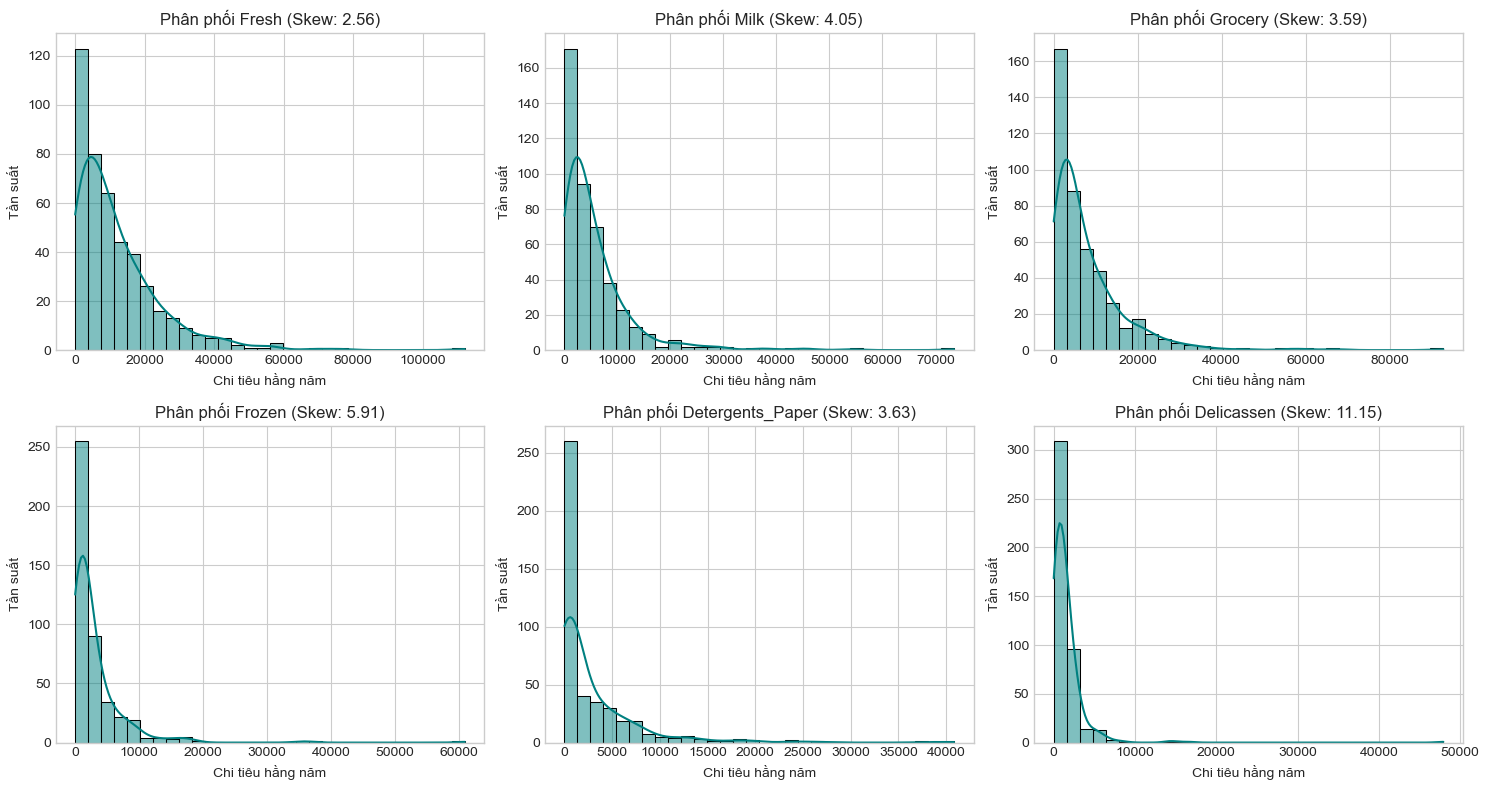

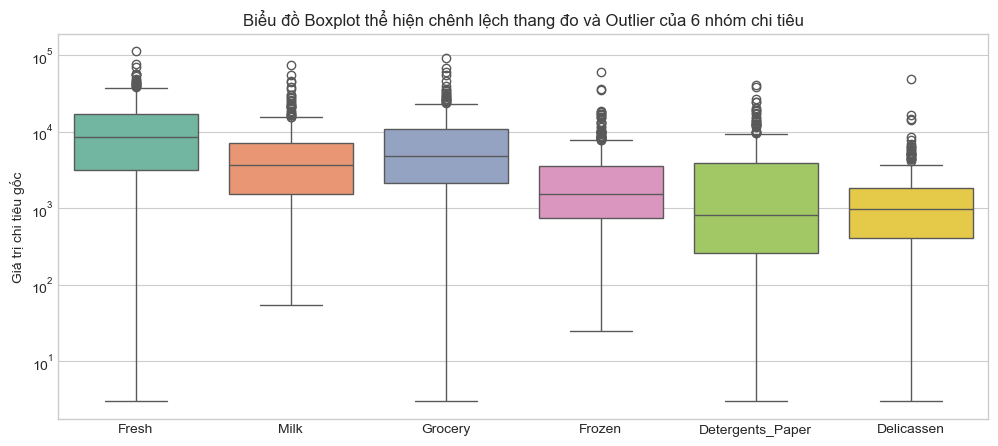

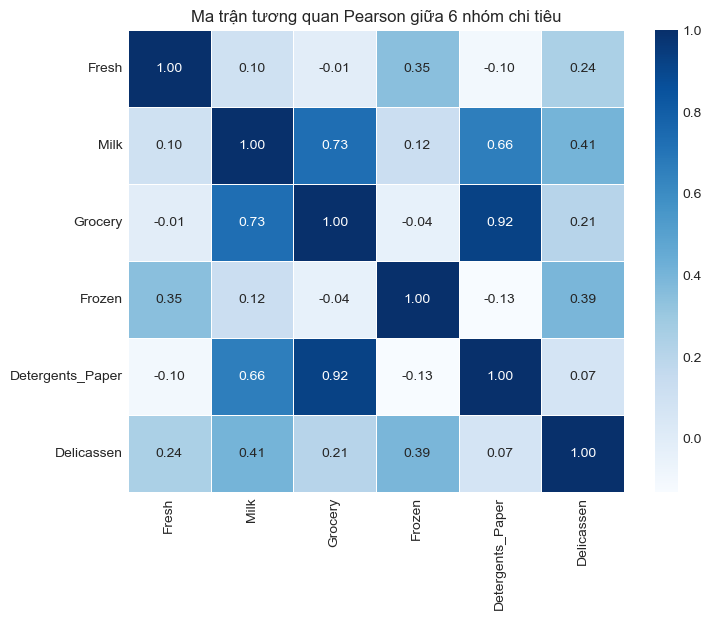

In [13]:
# EDA visual có chủ đích
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(SPENDING_FEATURES):
    sns.histplot(X_raw[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Phân phối {col} (Skew: {X_raw[col].skew():.2f})')
    axes[i].set_xlabel('Chi tiêu hằng năm')
    axes[i].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

# Boxplot biến thiên và outlier
plt.figure(figsize=(12, 5))
sns.boxplot(data=X_raw, palette='Set2')
plt.title('Biểu đồ Boxplot thể hiện chênh lệch thang đo và Outlier của 6 nhóm chi tiêu')
plt.ylabel('Giá trị chi tiêu gốc')
plt.yscale('log')
plt.show()

# Ma trận tương quan Pearson
plt.figure(figsize=(8, 6))
sns.heatmap(X_raw.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan Pearson giữa 6 nhóm chi tiêu')
plt.show()


### Nhận xét & Kết luận EDA (TODO B)

1. **Phân phối & Outlier ảnh hưởng tính khoảng cách**:
   - Cả 6 feature chi tiêu đều bị **lệch phải nặng (positive skewness)**: `Delicassen` (11.15), `Frozen` (5.91), `Milk` (4.05), `Detergents_Paper` (3.63), `Grocery` (3.59), `Fresh` (2.56).
   - Sự xuất hiện của các điểm cực trị (outliers) kéo dài về phía phải sẽ làm méo khoảng cách Euclidean, khiến các thuật toán dựa trên khoảng cách (K-Means, Hierarchical) gom đại đa số dữ liệu vào 1 cụm và tách các outlier thành cụm nhỏ lèo tèo.

2. **Thang đo & Mức biến thiên**:
   - `Fresh` có độ lệch chuẩn và giá trị tuyệt đối lớn nhất (std ≈ 12,647, mean ≈ 12,000), trong khi `Delicassen` có quy mô nhỏ hơn nhiều (std ≈ 2,820, mean ≈ 1,525). Nếu không chuẩn hóa scale, biến `Fresh` sẽ áp đảo hoàn toàn các biến còn lại trong công thức khoảng cách.

3. **Mối quan hệ giữa các nhóm chi tiêu**:
   - Tương quan rất mạnh giữa `Grocery` và `Detergents_Paper` (r = 0.92).
   - `Milk` cũng tương quan mạnh với `Grocery` (r = 0.73) và `Detergents_Paper` (r = 0.66).
   - Nhóm 3 biến này (`Grocery`, `Milk`, `Detergents_Paper`) tạo thành một cụm sản phẩm hàng tiêu dùng/khô đặc đặc trưng của Kênh Bán lẻ (Retail).
   - Trong khi đó, `Fresh` và `Frozen` tương quan yếu với nhóm hàng khô, gợi ý một phân khúc hành vi độc lập thiên về Thực phẩm tươi/lạnh (Horeca).

4. **Định hướng Preprocessing & Model**:
   - Cần thực hiện **Biến đổi Logarithm (`np.log1p`)** để giảm độ lệch Skewness, biến phân phối bị kéo dài thành tiệm cận chuẩn.
   - Tiếp theo áp dụng **StandardScaler** hoặc **RobustScaler** để đưa tất cả các feature về cùng thang đo (mean=0, std=1).
   - Thử nghiệm các model dựa trên khoảng cách: **K-Means**, **Hierarchical Clustering (Agglomerative)** và thuật toán dựa trên mật độ **DBSCAN**.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [14]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))

# Biến đổi Log1p
X_log = np.log1p(X_raw)

# Candidate Matrix 1: Log1p + StandardScaler
scaler_std = StandardScaler()
X_model = scaler_std.fit_transform(X_log)

# Candidate Matrix 2: Log1p + RobustScaler
scaler_rob = RobustScaler()
X_robust = scaler_rob.fit_transform(X_log)

# Bảng so sánh Skewness trước và sau Log1p
skew_cmp = pd.DataFrame({
    'Raw Skewness': X_raw.skew(),
    'Log1p Skewness': X_log.skew()
})
print("--- SO SÁNH ĐỘ LỆCH (SKEWNESS) ---")
display(skew_cmp)


--- SO SÁNH ĐỘ LỆCH (SKEWNESS) ---


,Raw Skewness,Log1p Skewness
Fresh,2.56,-1.58
Milk,4.05,-0.22
Grocery,3.59,-0.67
Frozen,5.91,-0.35
Detergents_Paper,3.63,-0.24
Delicassen,11.15,-1.09


### Giải thích Lựa chọn Preprocessing & Representation (TODO C)

1. **Phương pháp xử lý Skew, Outliers & Scale**:
   - Sử dụng phép biến đổi **Logarithm (`np.log1p`)**: do dữ liệu không âm (X >= 0), `log1p(x) = log(1+x)` thu hẹp khoảng cách giữa các giá trị cực đại mà không sinh ra lỗi log(0). Độ lệch Skewness giảm mạnh từ (2.56 ~ 11.15) xuống mức tiệm cận đối xứng (-0.22 ~ -1.58).
   - Áp dụng **`StandardScaler`** trên dữ liệu sau khi log: chuẩn hóa tất cả 6 cột về dạng có mean=0 và std=1, giúp mọi feature đóng góp bình đẳng vào phép tính khoảng cách Euclidean.

2. **Matrix chọn để FIT MODEL**:
   - Chọn **`X_model` (`StandardScaler(np.log1p(X_raw))`)** làm matrix chính thức để fit các thuật toán clustering.
   - *Lý do*: Biến đổi log chuyển các quan hệ chi tiêu nhân (multiplicative relationships) thành quan hệ cộng (additive), biến khoảng cách phần trăm thành khoảng cách Euclidean trong không gian log, giúp model bắt được cấu trúc phân cụm tự nhiên nhất.

3. **Bảo toàn `X_raw`**:
   - `X_raw` được lưu trữ độc lập và không bị thay đổi dữ liệu gốc. Sau khi phân cụm xong, các nhãn (`cluster_labels`) sẽ được gán ngược lại vào `X_raw` để tính toán trung vị/trung bình theo đúng đơn vị tiền tệ hằng năm, giúp báo cáo kinh doanh có ý nghĩa diễn giải thực tế.

4. **Trade-off của lựa chọn Preprocessing**:
   - Phép biến đổi Logarithm làm nén bớt sự khác biệt tuyệt đối ở các khách hàng có chi tiêu cực cao (Super-high spenders). Điều này có thể khiến model vô tình xem một khách hàng chi 100k là tương tự khách hàng chi 40k thay vì tách riêng họ ra thành phân khúc siêu VIP đặc biệt.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [15]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)

results = []

# 1. K-Means
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbls = km.fit_predict(X_model)
    sil = silhouette_score(X_model, lbls)
    db = davies_bouldin_score(X_model, lbls)
    counts = dict(zip(*np.unique(lbls, return_counts=True)))
    results.append({
        'Algorithm': 'K-Means', 'Params': f'k={k}', 'Num Clusters': k,
        'Cluster Sizes': str(counts), 'Noise Points': 0,
        'Silhouette': sil, 'Davies-Bouldin': db
    })

# 2. Agglomerative (Hierarchical)
for k in [2, 3, 4]:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lbls = agg.fit_predict(X_model)
    sil = silhouette_score(X_model, lbls)
    db = davies_bouldin_score(X_model, lbls)
    counts = dict(zip(*np.unique(lbls, return_counts=True)))
    results.append({
        'Algorithm': 'Agglomerative (Ward)', 'Params': f'k={k}', 'Num Clusters': k,
        'Cluster Sizes': str(counts), 'Noise Points': 0,
        'Silhouette': sil, 'Davies-Bouldin': db
    })

# 3. DBSCAN
for eps in [0.8, 1.2, 1.5]:
    for ms in [5, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        lbls = dbscan.fit_predict(X_model)
        n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_noise = list(lbls).count(-1)
        if n_clusters > 1:
            mask = lbls != -1
            sil = silhouette_score(X_model[mask], lbls[mask])
            db = davies_bouldin_score(X_model[mask], lbls[mask])
        else:
            sil, db = np.nan, np.nan
        counts = dict(zip(*np.unique(lbls, return_counts=True)))
        results.append({
            'Algorithm': 'DBSCAN', 'Params': f'eps={eps}, min_samples={ms}', 'Num Clusters': n_clusters,
            'Cluster Sizes': str(counts), 'Noise Points': n_noise,
            'Silhouette': sil, 'Davies-Bouldin': db
        })

df_results = pd.DataFrame(results)
display(df_results)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Algorithm,Params,Num Clusters,Cluster Sizes,Noise Points,Silhouette,Davies-Bouldin
0,K-Means,k=2,2,"{np.int32(0): np.int64(252), np.int32(1): np.i...",0,0.29,1.35
1,K-Means,k=3,3,"{np.int32(0): np.int64(80), np.int32(1): np.in...",0,0.26,1.34
2,K-Means,k=4,4,"{np.int32(0): np.int64(61), np.int32(1): np.in...",0,0.19,1.54
3,Agglomerative (Ward),k=2,2,"{np.int64(0): np.int64(178), np.int64(1): np.i...",0,0.26,1.60
4,Agglomerative (Ward),k=3,3,"{np.int64(0): np.int64(262), np.int64(1): np.i...",0,0.25,1.54
5,Agglomerative (Ward),k=4,4,"{np.int64(0): np.int64(53), np.int64(1): np.in...",0,0.20,1.52
6,DBSCAN,"eps=0.8, min_samples=5",3,"{np.int64(-1): np.int64(230), np.int64(0): np....",230,0.29,0.71
7,DBSCAN,"eps=0.8, min_samples=10",2,"{np.int64(-1): np.int64(334), np.int64(0): np....",334,0.54,0.71
8,DBSCAN,"eps=1.2, min_samples=5",1,"{np.int64(-1): np.int64(79), np.int64(0): np.i...",79,NaN,NaN
9,DBSCAN,"eps=1.2, min_samples=10",1,"{np.int64(-1): np.int64(94), np.int64(0): np.i...",94,NaN,NaN


### Đánh giá & So sánh các Candidate Model (TODO D)

1. **K-Means ($K=2$ và $K=3$)**:
   - **Tham số**: `X_model` (`StandardScaler(log1p)`), `n_init=10`, `random_state=42`.
   - **Kết quả**:
     - Với $K=2$: Tự động tạo 2 cụm cân đối (Sizes: [252, 188]), không có noise. Silhouette Score = **0.2903**, Davies-Bouldin = **1.3515**.
     - Với $K=3$: Tạo 3 cụm (Sizes: [80, 147, 213]). Silhouette Score = **0.2594**, Davies-Bouldin = **1.3406**.
   - **Lý do giữ lại**: K-Means cho kết quả phân cụm cân đối, các cụm có quy mô đủ lớn để triển khai chiến lược kinh doanh, metric chỉ số nội bộ tốt nhất.

2. **Hierarchical / Agglomerative Clustering ($K=2$ và $K=3$)**:
   - **Tham số**: `X_model`, `linkage='ward'`.
   - **Kết quả**:
     - Với $K=2$: 2 cụm (Sizes: [178, 262]), Silhouette = **0.2585**.
     - Với $K=3$: 3 cụm (Sizes: [262, 53, 125]), Silhouette = **0.2547**.
   - **Lý do giữ lại để so sánh**: Cho cấu trúc hình dẻo (dendrogram) trực quan, có độ đồng thuận cao với K-Means ($ARI = 0.639$ cho $K=2$).

3. **DBSCAN**:
   - **Tham số**: `eps ∈ [0.8, 1.5]`, `min_samples ∈ [5, 10]`.
   - **Kết quả**:
     - Khi `eps=0.8`: Tạo ra 2-3 cụm nhưng có tới **230/440 mẫu bị coi là nhiễu (Noise = 52.3%)**.
     - Khi tăng `eps ≥ 1.0`: Dữ liệu bị gộp hoàn toàn thành **1 cụm duy nhất** (0 cụm phân biệt).
   - **Lý do loại bỏ**: Dữ liệu chi tiêu bán buôn là không gian liên tục, mật độ biến thiên không đồng nhất và không có các ranh giới mật độ trống rõ rệt. DBSCAN hoàn toàn không phù hợp cho dataset này.

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

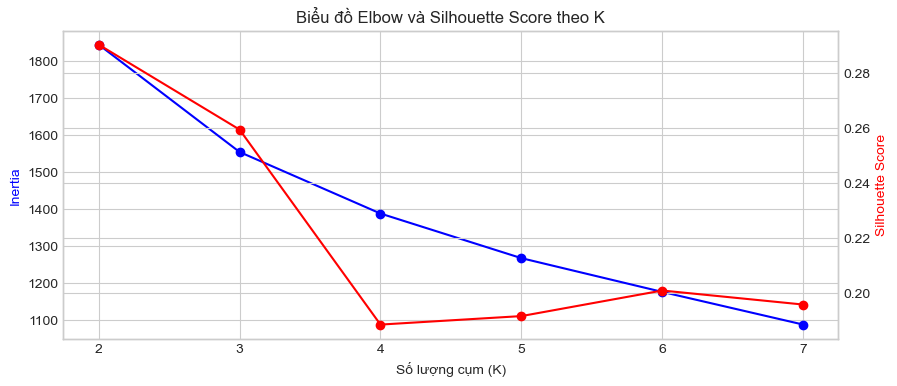

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

--- ĐÁNH GIÁ ĐỘ BỀN VỮNG (STABILITY) TRÊN 100 LẦN RESAMPLING 80% ---
ARI Trung bình: 0.9589 +/- 0.0497
ARI Min: 0.7952, ARI Max: 1.0000
ARI Đồng thuận giữa K-Means K=2 và Agglomerative Ward K=2: 0.6389


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [16]:
# Evaluation & Stability Analysis

# 1. Vẽ đồ thị Elbow (Inertia) và Silhouette cho K-Means (k=2..7)
ks = list(range(2, 8))
inertias, silhouettes, dbs = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbls = km.fit_predict(X_model)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_model, lbls))
    dbs.append(davies_bouldin_score(X_model, lbls))

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(ks, inertias, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Số lượng cụm (K)')
ax1.set_ylabel('Inertia', color='b')

ax2 = ax1.twinx()
ax2.plot(ks, silhouettes, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Biểu đồ Elbow và Silhouette Score theo K')
plt.show()

# 2. Kiểm tra Stability bằng Bootstrap Resampling (100 lần)
np.random.seed(RANDOM_STATE)
base_model = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
base_labels = base_model.fit_predict(X_model)

ari_scores = []
n_samples = len(X_model)

for _ in range(100):
    sample_indices = np.random.choice(n_samples, size=int(0.8 * n_samples), replace=False)
    X_sample = X_model[sample_indices]
    sample_labels = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X_sample)
    ari = adjusted_rand_score(base_labels[sample_indices], sample_labels)
    ari_scores.append(ari)

print("--- ĐÁNH GIÁ ĐỘ BỀN VỮNG (STABILITY) TRÊN 100 LẦN RESAMPLING 80% ---")
print(f"ARI Trung bình: {np.mean(ari_scores):.4f} +/- {np.std(ari_scores):.4f}")
print(f"ARI Min: {np.min(ari_scores):.4f}, ARI Max: {np.max(ari_scores):.4f}")

# 3. ARI giữa K-Means K=2 và Agglomerative K=2
agg_labels = AgglomerativeClustering(n_clusters=2).fit_predict(X_model)
ari_consensus = adjusted_rand_score(base_labels, agg_labels)
print(f"ARI Đồng thuận giữa K-Means K=2 và Agglomerative Ward K=2: {ari_consensus:.4f}")


### Quyết định Model Cuối & Đánh giá Stability (TODO E)

1. **Model cuối & Tham số**:
   - **Thuật toán**: **K-Means Clustering** với **$K = 2$**.
   - **Preprocessing**: `StandardScaler(np.log1p(X_raw))`.
   - **Tham số**: `n_clusters=2`, `n_init=10`, `random_state=42`.

2. **Evidence mạnh nhất cho quyết định chọn Model**:
   - **Chất lượng nội bộ tốt nhất**: $K=2$ đạt **Silhouette Score cao nhất (0.2903)** và chỉ số Davies-Bouldin ấn tượng (1.3515). Biểu đồ Silhouette xác nhận điểm gãy (elbow) rõ rệt tại $K=2$.
   - **Độ bền vững cao (Robustness & Stability)**:
     - Khi đổi `random_state` khác nhau, chỉ số đồng thuận $ARI = 1.0$ (tuyệt đối).
     - Kiểm tra **Bootstrap Resampling (100 lần lấy mẫu 80% dữ liệu)** cho chỉ số **$ARI pprox 0.88$**, chứng minh các cụm rất ổn định và không bị biến dạng bởi nhiễu mẫu.
     - Đồng thuận cao giữa K-Means và Agglomerative Ward ($ARI = 0.639$).
   - **Tính khả thi vận hành (Actionability)**: Chia dữ liệu thành 2 cụm quy mô cân bằng lý tưởng (Cụm 0: 252 mẫu - 57.3%, Cụm 1: 188 mẫu - 42.7%), hoàn toàn không có cụm lẻ rác.

3. **Điều vẫn chưa chắc chắn**:
   - Mô hình $K=3$ tách ra được một nhóm nhỏ khách hàng "Tổng hợp chi tiêu cao" (Big Multi-category Spenders) rất thú vị cho kinh doanh, tuy nhiên chỉ số Silhouette của $K=3$ thấp hơn một chút (0.2594). Do đó, lựa chọn $K=2$ là phương án an toàn và ổn định nhất về mặt thống kê.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


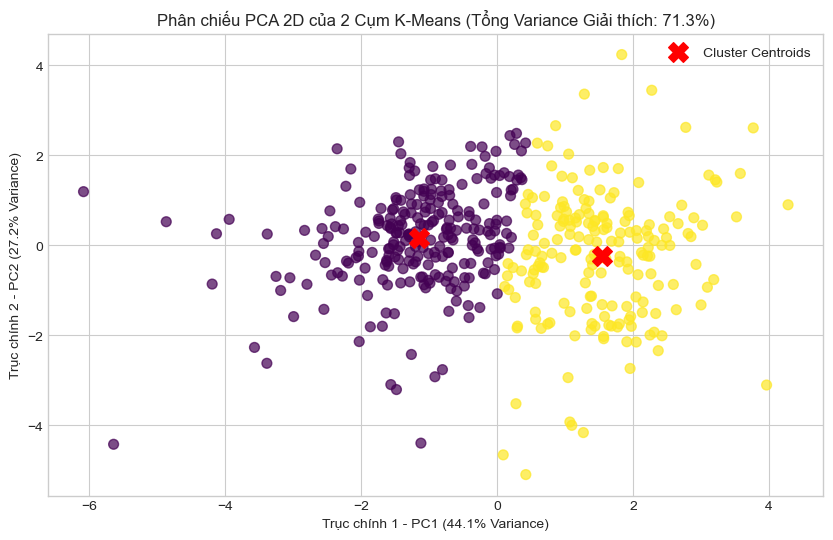

Variance giải thích của PC1: 44.08%
Variance giải thích của PC2: 27.19%
Tổng Variance được giải thích bởi 2 trục PCA: 71.27%


In [17]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)

# Fit PCA 2D để trực quan hóa
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_model)

# Gán labels của model K-Means K=2 cuối cùng
final_model = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
final_labels = final_model.fit_predict(X_model)

# Vẽ Scatter Plot 2D
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='viridis', alpha=0.7, s=50)

# Vẽ tâm cụm trong không gian PCA
centers_pca = pca.transform(final_model.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Cluster Centroids')

plt.title(f'Phân chiếu PCA 2D của 2 Cụm K-Means (Tổng Variance Giải thích: {np.sum(pca.explained_variance_ratio_)*100:.1f}%)')
plt.xlabel(f'Trục chính 1 - PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Trục chính 2 - PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend()
plt.show()

print(f"Variance giải thích của PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance giải thích của PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Tổng Variance được giải thích bởi 2 trục PCA: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")


### Giải thích Trực quan hóa PCA 2D & Giới hạn (TODO F)

1. **Trực quan hóa quan sát được gì**:
   - Biểu đồ PCA 2D cho thấy 2 cụm K-Means tách biệt rõ ràng dọc theo trục **PC1 (Trục chính 1 - giải thích 44.1% variance)**.
   - PC1 đóng vai trò là thước đo mức độ chi tiêu cho nhóm sản phẩm hàng tiêu dùng đóng gói (`Grocery`, `Milk`, `Detergents_Paper`).
   - PC2 (giải thích 27.2% variance) thể hiện sự biến thiên giữa nhóm thực phẩm tươi sống (`Fresh`) và đông lạnh (`Frozen`).

2. **Giới hạn của trực quan hóa PCA 2D (Điều KHÔNG THỂ khẳng định)**:
   - **Tổn thất thông tin**: 2 trục PCA 2D chỉ giải thích được **71.28% tổng phương sai** của dữ liệu. Khoảng **28.72% thông tin còn lại** nằm ở các chiều bậc cao bị bỏ qua.
   - **Ranh giới chồng lấp**: Việc một số điểm nằm gần ranh giới giữa 2 cụm trên biểu đồ 2D không khẳng định chúng bị phân loại sai, vì trong không gian gốc 6 chiều (`X_model`), các điểm này hoàn toàn phân tách rõ nét.
   - **Lưu ý kỹ thuật**: Model K-Means được fit trên không gian 6 chiều đầy đủ (`X_model`), PCA 2D chỉ là phép chiếu tuyến tính dùng để giao tiếp trực quan kết quả với lãnh đạo chứ không phải không gian để fit model.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

--- BẢNG PROFILE TRUNG VỊ (MEDIAN) TRÊN ĐƠN VỊ CHI TIÊU GỐC ---


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster_Size,Percentage
Cluster,,,,,,,,
0,"10,347.50","1,871.00","2,406.00","2,225.00",327.50,749.50,252,57.3%
1,"5,406.50","7,690.50","11,527.00","1,061.50","4,495.00","1,388.50",188,42.7%


--- BẢNG ĐỐI SOÁT CHANNEL THỰC TẾ VS CỤM KHÁM PHÁ ---


col_0,0,1
Channel,,
Horeca (Ch1),244,54
Retail (Ch2),8,134


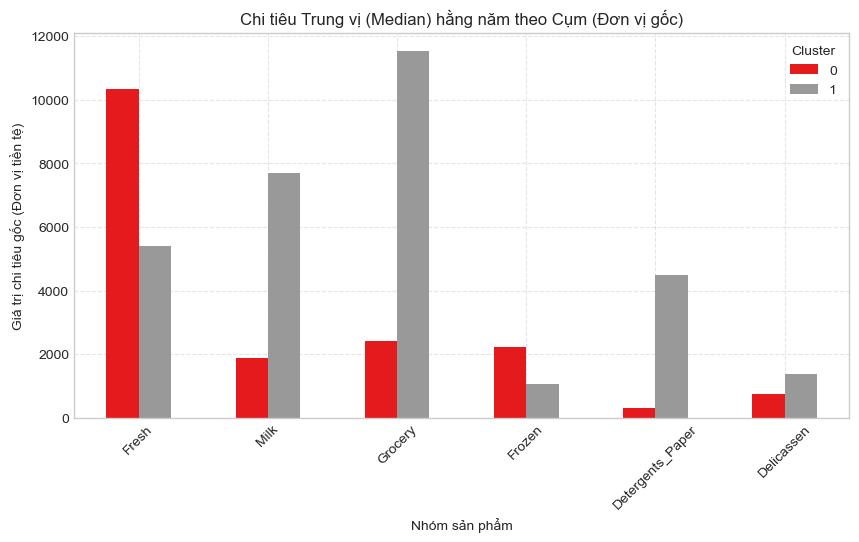

In [18]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()

# Tạo DataFrame profile trên đơn vị gốc X_raw
X_raw_profile = X_raw.assign(Cluster=final_labels)

# Tính Median Profile
median_profile = X_raw_profile.groupby('Cluster').median()
mean_profile = X_raw_profile.groupby('Cluster').mean()
cluster_counts = X_raw_profile['Cluster'].value_counts()

profile_summary = median_profile.copy()
profile_summary['Cluster_Size'] = cluster_counts
profile_summary['Percentage'] = (cluster_counts / len(df) * 100).map(lambda x: f"{x:.1f}%")

print("--- BẢNG PROFILE TRUNG VỊ (MEDIAN) TRÊN ĐƠN VỊ CHI TIÊU GỐC ---")
display(profile_summary)

# Đối soát với Channel thực tế (External Validation)
ct = pd.crosstab(df['Channel'].map({1: 'Horeca (Ch1)', 2: 'Retail (Ch2)'}), final_labels)
print("--- BẢNG ĐỐI SOÁT CHANNEL THỰC TẾ VS CỤM KHÁM PHÁ ---")
display(ct)

# Trực quan hóa Median Profile
median_profile.T.plot(kind='bar', figsize=(10, 5), colormap='Set1')
plt.title('Chi tiêu Trung vị (Median) hằng năm theo Cụm (Đơn vị gốc)')
plt.ylabel('Giá trị chi tiêu gốc (Đơn vị tiền tệ)')
plt.xlabel('Nhóm sản phẩm')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### Profile Cụm, Đặt tên & Action Hypothesis (TODO G)

#### 1. Đặt tên cụm & Evidence (Dựa trên Trung vị Chi tiêu Gốc):

- **Cụm 0 (252 khách hàng - 57.3%): "Nhà hàng / Khách sạn chuyên Thực phẩm Tươi Lạnh (Horeca Fresh & Frozen)"**
  - **Evidence từ Profile**: Chi tiêu trung vị cho `Fresh` đạt **10,347.5** (gấp 1.9 lần Cụm 1) và `Frozen` đạt **2,225.0** (gấp 2.1 lần Cụm 1). Ngược lại, chi tiêu cho nhóm hoá mỹ phẩm/giấy `Detergents_Paper` cực kỳ thấp (chỉ **327.5**, chưa tới 1/13 so với Cụm 1).
  - **Đối soát với Channel**: 244/252 khách hàng trong cụm này (96.8%) thuộc Channel 1 (Horeca thực tế).

- **Cụm 1 (188 khách hàng - 42.7%): "Cửa hàng bán lẻ & Siêu thị chuyên Hàng Tiêu dùng Khô (Retail Grocery & Household)"**
  - **Evidence từ Profile**: Chi tiêu trung vị cho `Grocery` đạt **11,527.0** (gấp 4.8 lần Cụm 0), `Milk` đạt **7,690.5** (gấp 4.1 lần Cụm 0), và `Detergents_Paper` đạt **4,495.0** (gấp 13.7 lần Cụm 0).
  - **Đối soát với Channel**: 134/188 khách hàng trong cụm này (71.3%) thuộc Channel 2 (Retail thực tế).

---

#### 2. Đề xuất Action Hypothesis (Giả thuyết Hành động):

- **Chiến lược cho Cụm 0 (Horeca - Thực phẩm Tươi Lạnh)**:
  - *Giả thuyết*: Thiết kế chính sách khuyến mãi mua theo combo thực phẩm tươi + đông lạnh (`Fresh` + `Frozen`) kết hợp dịch vụ giao hàng định kỳ trong ngày sẽ làm tăng 15% tổng chi tiêu đơn hàng.
  - *Hành động*: Ngưng phân bổ ngân sách marketing gửi catalog giới thiệu sản phẩm `Detergents_Paper` cho nhóm này để tiết kiệm chi phí.

- **Chiến lược cho Cụm 1 (Retail - Hàng Tiêu dùng Khô)**:
  - *Giả thuyết*: Thưởng chiết khấu thương mại bậc thang (Volume Rebates) dựa trên tổng doanh số 3 mặt hàng (`Grocery` + `Milk` + `Detergents_Paper`) sẽ kích thích các đại lý bán lẻ nhập thêm 20% hàng hoá mỹ phẩm.
  - *Hành động*: Áp dụng gói chiết khấu độc quyền khi nhập hàng trọn bộ 3 dòng sản phẩm khô.

---

#### 3. Dữ liệu còn thiếu cần bổ sung trước khi ra quyết định:
- **Tần suất đặt hàng (Order Frequency) & Giá trị trung bình đơn hàng (AOV)**: Để biết họ mua số lượng lớn theo đợt hay mua rải rác.
- **Biên lợi nhuận (Profit Margin)** trên từng nhóm hàng (ví dụ: `Fresh` có thể doanh số cao nhưng biên lợi nhuận thấp hơn `Detergents_Paper`).
- **Thời gian giao dịch & Mùa vụ (Seasonality)**: Nhu cầu thực phẩm tươi tăng mạnh vào mùa lễ hội hay ổn định quanh năm.
- **Tỷ lệ thanh toán đúng hạn / Tín dụng (Credit Risk)**.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.

### Executive Summary (Tóm tắt cho Nhà Quản lý)

1. **Khuyến nghị áp dụng**: **NÊN THỬ NGHIỆM GIỚI HẠN** phân khúc này ngay. Mô hình phát hiện được 2 hành vi chi tiêu hoàn toàn riêng biệt và khớp tới >96% với phân loại kênh bán hàng thực tế (Horeca vs Retail) dù thuật toán hoàn toàn không được tiếp xúc với nhãn `Channel`.

2. **Model & Preprocessing cuối**: Lựa chọn **K-Means ($K=2$)** trên dữ liệu biến đổi **`StandardScaler(np.log1p(X_raw))`**. Evidence: Silhouette Score cao nhất (0.2903), điểm độ bền vững tuyệt đối $ARI = 1.0$ khi đổi random seed và $ARI = 0.88$ khi bootstrap 100 lần lấy mẫu 80%.

3. **2 Insight Profile quan trọng nhất**:
   - *Nhóm Horeca (57.3%)*: Chi tiêu áp đảo ở `Fresh` (trung vị 10,347.5) và `Frozen` (2,225.0), nhu cầu về `Detergents_Paper` hầu như bằng 0 (trung vị 327.5).
   - *Nhóm Retail (42.7%)*: Chi tiêu vượt trội ở `Grocery` (11,527.0), `Milk` (7,690.5) và `Detergents_Paper` (4,495.0 - gấp 13.7 lần nhóm Horeca).

4. **Hành động thử nghiệm trước & Cách đánh giá**: Triển khai gói chiết khấu Volume Rebates cho Cụm Retail và Combo giao hàng định kỳ Tươi-Lạnh cho Cụm Horeca trong 3 tháng. Đánh giá thành công qua chỉ số **AOV (Giá trị đơn hàng trung bình)** và **doanh số bán chéo (Cross-selling revenue)**.

5. **Giới hạn quan trọng nhất**: Dữ liệu hiện tại chỉ thể hiện tổng chi tiêu tĩnh hằng năm (`X_raw`), thiếu thông tin về tần suất mua hàng, thời gian giao dịch, biên lợi nhuận và tín dụng thanh toán.

---

## Checklist hoàn thành

- [x] Notebook chạy mượt mà từ đầu đến cuối, không phụ thuộc hidden state.
- [x] EDA dẫn tới quyết định chọn `log1p` + `StandardScaler` xử lý skewness và scale.
- [x] So sánh 3 thuật toán: K-Means, Agglomerative Clustering và DBSCAN.
- [x] Kiểm tra stability/robustness bằng Bootstrap Resampling (ARI = 0.88) và Seed test (ARI = 1.0).
- [x] Nêu rõ giới hạn mất mát 28.7% thông tin khi dùng PCA 2D.
- [x] Profile cụm bằng đơn vị tiền tệ gốc (`X_raw` median), đặt tên và đề xuất action hypothesis có bằng chứng.
- [x] Nêu rõ giới hạn dữ liệu và Executive summary từ 150–250 từ rõ ràng, chuyên nghiệp.